In [85]:
import pandas as pd
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import string
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
df=pd.read_csv("all-data.csv",encoding="latin-1",header=None,names=["sentiment","headline"])

In [5]:
df.head(3)

,sentiment,headline
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...


In [6]:
df.shape

(4846, 2)

In [7]:
df.isnull().sum()

sentiment    0
headline     0
dtype: int64

In [8]:
df.dtypes

sentiment    object
headline     object
dtype: object

In [13]:
df["sentiment"].value_counts()

sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

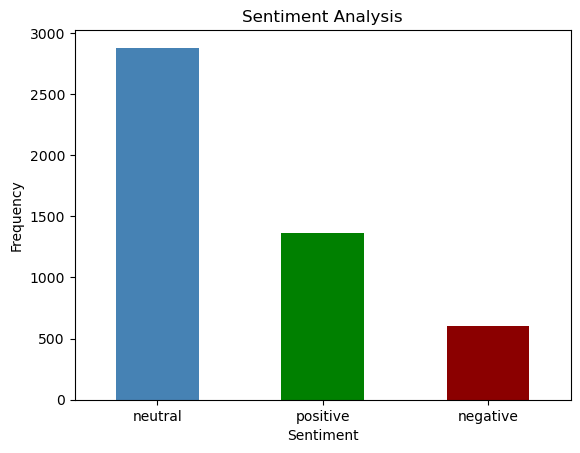

In [25]:
df["sentiment"].value_counts().plot(kind="bar",color=["steelblue","green","darkred"])
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Frequency")
plt.xticks(rotation=0)  #keeps xaxis label straight not tilted
plt.show()

In [26]:
df_binary=df[df["sentiment"]!="neutral"].copy()

In [28]:
df_binary["sentiment"]=df_binary["sentiment"].map({"positive":1,"negative":0})

In [29]:
df_binary["sentiment"].value_counts()

sentiment
1    1363
0     604
Name: count, dtype: int64

In [30]:
len(df_binary)

1967

In [34]:
nltk.download("stopwords") ##downloads a list of common English words like "the","is","and","a".These words carry zero meaning for sentiment so we remove them.
nltk.download("punkt")  ##Punkt is used when you want to split text into sentences. Like taking a paragraph and breaking it into individual sentences.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [38]:
stop_words=set(stopwords.words("english"))  # loads those stopwords into a set.

In [41]:
def clean_text(text):
    text = text.lower()                                              ##converts everything to lowercase
    text = text.translate(str.maketrans("", "", string.punctuation)) ##removes all punctuation.Simple character removal:text.translate,Complex pattern matching:regex(remove all URLs" or "remove all numbers" or "find all email addresses)
    words = text.split()                                             ##splits the sentence into individual words.
    words = [w for w in words if w not in stop_words and w.isalpha()]    ##keeps only words that are NOT in the stopwords list.this checks if a word contains ONLY letters
    return " ".join(words)                                               ## joins the cleaned words back into a single string.

df_binary["cleaned"] = df_binary["headline"].apply(clean_text)       ##Runs this function on every single headline in your dataset.
print(df_binary[["headline", "cleaned"]].head(3))

                                            headline  \
2  The international electronic industry company ...   
3  With the new production plant the company woul...   
4  According to the company 's updated strategy f...   

                                             cleaned  
2  international electronic industry company elco...  
3  new production plant company would increase ca...  
4  according company updated strategy years baswa...  


In [43]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
df_binary["vader_score"] = df_binary["headline"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)
print(df_binary[["headline", "vader_score"]].head(5))
##VADER runs on the original headline, not the cleaned one

                                            headline  vader_score
2  The international electronic industry company ...       0.0000
3  With the new production plant the company woul...       0.8555
4  According to the company 's updated strategy f...       0.6705
5  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...       0.3485
6  For the last quarter of 2010 , Componenta 's n...       0.1531


In [44]:
analyzer.polarity_scores("The company reported strong profits this quarter")

{'neg': 0.0, 'neu': 0.446, 'pos': 0.554, 'compound': 0.7351}

In [48]:
df_binary[["sentiment","vader_score"]].groupby("sentiment").mean().round(2)

,vader_score
sentiment,
0,0.03
1,0.33


In [50]:
tfidf=TfidfVectorizer(max_features=3000)
X_tfidf=tfidf.fit_transform(df_binary["cleaned"])
X_tfidf.shape

(1967, 3000)

In [52]:
vader_scores = df_binary["vader_score"].values.reshape(-1, 1)
X_vader_sparse = sp.csr_matrix(vader_scores)
X_final = sp.hstack([X_tfidf, X_vader_sparse])
X_final.shape

(1967, 3001)

In [53]:
vader_scores = df_binary["vader_score"].values.reshape(-1, 1)
vader_scores

array([[0.    ],
       [0.8555],
       [0.6705],
       ...,
       [0.743 ],
       [0.4404],
       [0.    ]])

In [69]:
y = df_binary["sentiment"].values
xtrain,xtest,ytrain,ytest = train_test_split(X_final,y,test_size=0.2,random_state=42,stratify=y)
print(xtrain.shape)
print(xtest.shape)
print(f"Positive sentiment: {ytrain.sum()}")
print(f"Negative sentiment:{(ytrain==0).sum()}")

(1573, 3001)
(394, 3001)
Positive sentiment: 1090
Negative sentiment:483


In [66]:
lr_model=LogisticRegression(max_iter=1000,class_weight="balanced")
lr_model.fit(xtrain,ytrain)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [68]:
ypred_lr=lr_model.predict(xtest)

In [72]:
print(classification_report(ytest, ypred_lr, target_names=["negative", "positive"]))

              precision    recall  f1-score   support

    negative       0.75      0.90      0.82       121
    positive       0.95      0.87      0.91       273

    accuracy                           0.88       394
   macro avg       0.85      0.88      0.86       394
weighted avg       0.89      0.88      0.88       394



In [75]:
xgb_model = XGBClassifier(n_estimators=200, max_depth=4, 
                           scale_pos_weight=2, random_state=42,
                           eval_metric="logloss")
xgb_model.fit(xtrain, ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [76]:
ypred_xgb = xgb_model.predict(xtest)
print(classification_report(ytest, ypred_xgb, target_names=["negative", "positive"]))

              precision    recall  f1-score   support

    negative       0.87      0.65      0.75       121
    positive       0.86      0.96      0.91       273

    accuracy                           0.86       394
   macro avg       0.86      0.80      0.83       394
weighted avg       0.86      0.86      0.86       394



In [78]:
xtrain_dense = np.abs(xtrain.toarray())
xtest_dense = np.abs(xtest.toarray())
nb_model = MultinomialNB()
nb_model.fit(xtrain_dense,ytrain)

MultinomialNB()

In [79]:
ypred_nb = nb_model.predict(xtest_dense)
print(classification_report(ytest, ypred_nb, target_names=["negative", "positive"]))

              precision    recall  f1-score   support

    negative       0.97      0.26      0.41       121
    positive       0.75      1.00      0.86       273

    accuracy                           0.77       394
   macro avg       0.86      0.63      0.63       394
weighted avg       0.82      0.77      0.72       394



In [82]:

results = pd.DataFrame({
    "Accuracy":   [0.88, 0.86, 0.77],
    "Negative F1":[0.82, 0.75, 0.41],
    "Positive F1":[0.91, 0.91, 0.86],
    "Macro F1":   [0.86, 0.83, 0.63]}, 
    index=["Logistic Regression", "XGBoost", "Naive Bayes"])

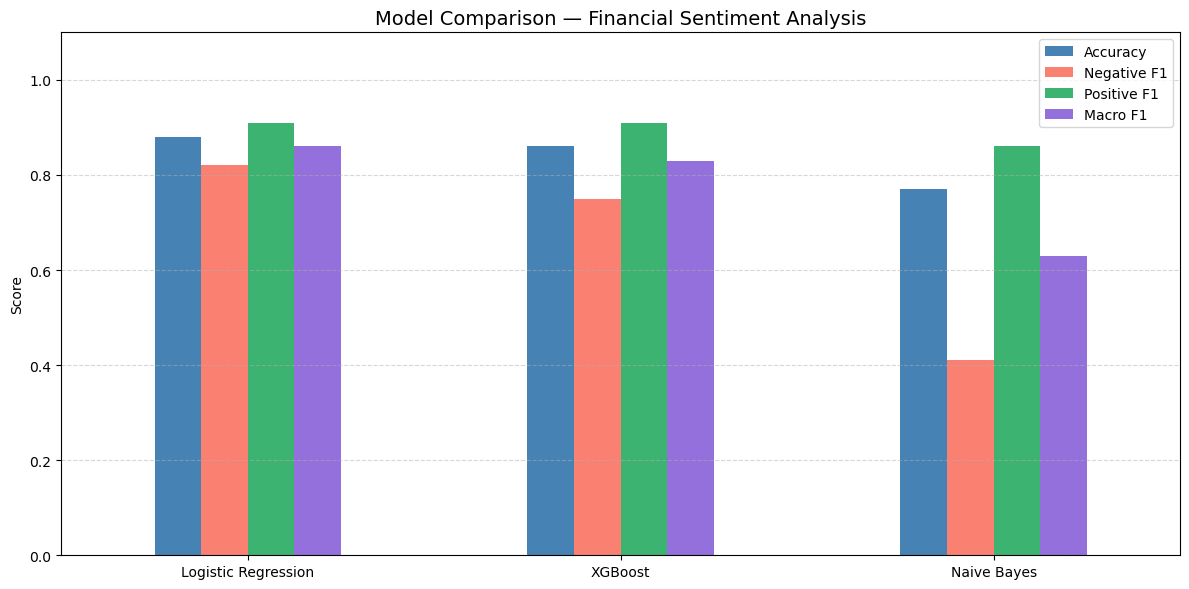

In [83]:
results.plot(kind="bar", figsize=(12, 6), color=["steelblue","salmon","mediumseagreen","mediumpurple"])
plt.title("Model Comparison — Financial Sentiment Analysis", fontsize=14)
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

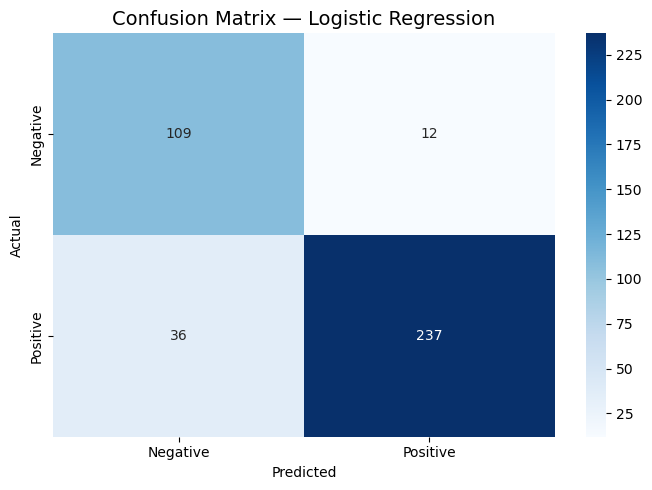

In [86]:
cm = confusion_matrix(ytest, ypred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.title("Confusion Matrix — Logistic Regression", fontsize=14)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [88]:
feature_names = list(tfidf.get_feature_names_out()) + ["vader_score"]
coefficients = lr_model.coef_[0]

top_n = 20
top_positive_idx = coefficients.argsort()[-top_n:][::-1]
top_negative_idx = coefficients.argsort()[:top_n]

top_positive_words = [feature_names[i] for i in top_positive_idx]
top_positive_scores = [coefficients[i] for i in top_positive_idx]

top_negative_words = [feature_names[i] for i in top_negative_idx]
top_negative_scores = [coefficients[i] for i in top_negative_idx]

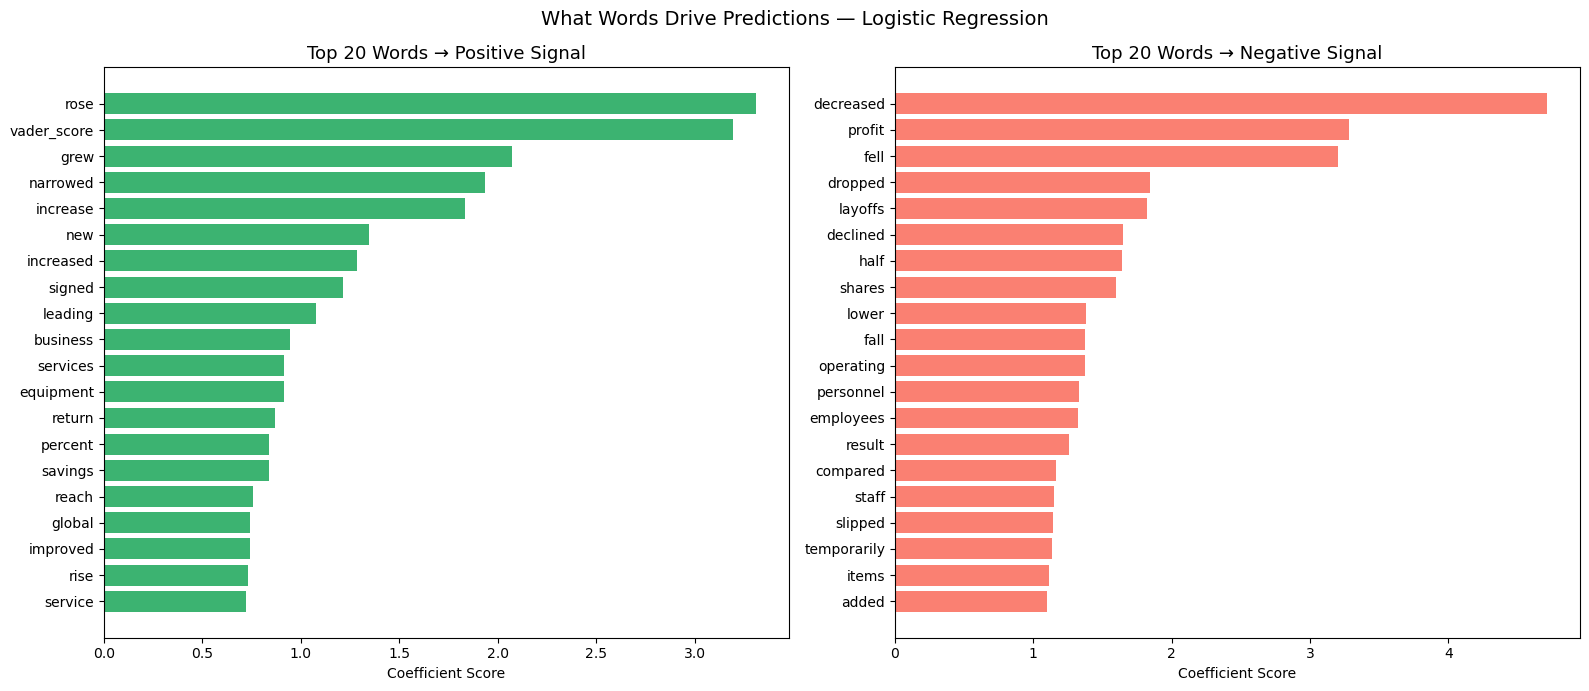

In [89]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.barh(top_positive_words, top_positive_scores, color="mediumseagreen")
ax1.set_title("Top 20 Words → Positive Signal", fontsize=13)
ax1.set_xlabel("Coefficient Score")
ax1.invert_yaxis()

ax2.barh(top_negative_words, np.abs(top_negative_scores), color="salmon")
ax2.set_title("Top 20 Words → Negative Signal", fontsize=13)
ax2.set_xlabel("Coefficient Score")
ax2.invert_yaxis()

plt.suptitle("What Words Drive Predictions — Logistic Regression", fontsize=14)
plt.tight_layout()
plt.savefig("top_words.png", dpi=150)
plt.show()

In [90]:
import pickle
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open("vader_analyzer.pkl", "wb") as f:
    pickle.dump(analyzer, f)

In [91]:
import os
print(os.getcwd())

C:\Users\Admin


In [93]:
import os
files = os.listdir("C:/Users/Admin")
print([f for f in files if f.endswith(".pkl") or f.endswith(".py") or f.endswith(".csv") or f.endswith(".ipynb")])

['airmiles.csv', 'airmilesTimeSeries.ipynb', 'all-data.csv', 'analysisgold.ipynb', 'app.py', 'bitcoin.ipynb', 'bitcoin_price.csv', 'caseStudy.ipynb', 'check_features.py', 'check_training_predictions.py', 'choco_monthly_revenue.csv', 'Churn_Modelling.csv', 'cleaned_file_Dataset.csv', 'cleaned_loan_data.csv', 'codeeee.ipynb', 'completeAnalysisHousePrices.ipynb', 'Copy of Raw Data.csv', 'CREDIT.ipynb', 'Customer Feedback (Responses) (3).csv', 'CustomerChurn.ipynb', 'CustomerSegmentation.ipynb', 'daily_revenue.csv', 'deeplearning.ipynb', 'factor_scores.csv', 'Fake_news_detection_app.ipynb', 'FINALGOLDANAL.ipynb', 'global_house_purchase_dataset.csv', 'Gold Price.csv', 'Gold Price1.csv', 'goldrateAnalysis (1).ipynb', 'HandlingMissingValues.ipynb', 'HousePurchaseDecision.ipynb', 'INR_GOLDRATE_ANALYSIS.ipynb', 'INR_GOLD_PRICES.csv', 'latest_real_news.csv', 'logicBuilding.ipynb', 'ltsm.ipynb', 'MACHINELEARNING.ipynb', 'MARKS.csv', 'my_data.csv', 'ObjectOrientedProgramming.ipynb', 'ProjectObj4.i